# MNIST Classification With Learned Superposition Activations

This notebook runs on the **full MNIST** split from sklearn/OpenML (~70k samples). The first run downloads MNIST and caches it locally.

Training uses **JAX + Optax** when available (`pip install "qfun[gpu]"`, then install a [CUDA-enabled jaxlib](https://jax.readthedocs.io/en/latest/installation.html) on Linux or Windows for GPU). The same code path runs on CPU if only the CPU jaxlib is installed. Without JAX, set `use_jax=False` in the config (PennyLane autograd over the full set can be very slow).

Features are **standardized** and compressed with **PCA** before baselines and quantum models.


In [1]:
import sys
from pathlib import Path

for _p in (Path.cwd(), Path.cwd().parent):
    if (_p / "qfun").is_dir():
        _root = str(_p.resolve())
        if _root not in sys.path:
            sys.path.insert(0, _root)
        break

from qfun.datasets import load_classification_dataset, prepare_classification_split
from qfun.qfan._classification_benchmarks import (
    build_comparison_rows,
    display_baseline_suite,
    display_quantum_result,
    print_comparison_table,
    print_split_summary,
    plot_training_diagnostics,
    run_default_baseline_suite,
    run_quantum_experiment,
)


## Config

Defaults mirror notebook 08. `use_jax=True` enables minibatch Adam on JAX (CPU or GPU). Without JAX installed, set `use_jax=False` (expect long runtimes on ~52k training points). Use `log_every=1` for a loss line every epoch and `show_training_progress=True` with `tqdm` installed for a live minibatch bar (JAX) or epoch bar (PennyLane).


In [2]:
data_seed = 7
test_size = 0.25
pca_components = 32

hidden_units = 6
n_qubits = 3
steps = 60
learning_rate = 0.04
log_every = 1  # print train loss every epoch; set higher to reduce console noise
show_training_progress = True  # tqdm bar if installed: pip install tqdm
snapshot_interval = 5
eval_shots = 3_000

try:
    import jax  # noqa: F401

    use_jax = True
except ImportError:
    use_jax = False
    print('Tip: pip install "qfun[gpu]" for JAX training on full MNIST (much faster).')

batch_size = 1024


## 1. Load, standardize, and compress MNIST

`load_classification_dataset("mnist")` may download once via sklearn/OpenML. We stratify the train/test split on labels, **standardize** 784-dimensional pixels, and apply **PCA** to `pca_components` dimensions before any model training.


In [3]:
mnist_dataset = load_classification_dataset("mnist")
mnist_split = prepare_classification_split(
    mnist_dataset,
    test_size=test_size,
    seed=data_seed,
    standardize=True,
    pca_components=pca_components,
)
class_names = mnist_split.target_names
print(f"Dataset size: {mnist_dataset.X.shape[0]} samples (full MNIST)")
print_split_summary(mnist_dataset.name, mnist_split)


Dataset size: 70000 samples (full MNIST)
Dataset: Mnist
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Training set: 52500 samples
Test set:     17500 samples
Feature dimension: 32
Train class counts: [5177 5908 5242 5356 5118 4735 5157 5470 5119 5218]
Test class counts:  [1726 1969 1748 1785 1706 1578 1719 1823 1706 1740]
PCA components: 32


## 2. Baselines


LogisticRegression
  accuracy = 0.8901
  macro-F1 = 0.8882
              precision    recall  f1-score   support

           0      0.939     0.948     0.944      1726
           1      0.942     0.961     0.951      1969
           2      0.876     0.864     0.870      1748
           3      0.861     0.858     0.859      1785
           4      0.887     0.911     0.899      1706
           5      0.846     0.800     0.823      1578
           6      0.921     0.940     0.930      1719
           7      0.913     0.917     0.915      1823
           8      0.845     0.824     0.834      1706
           9      0.854     0.859     0.856      1740

    accuracy                          0.890     17500
   macro avg      0.888     0.888     0.888     17500
weighted avg      0.889     0.890     0.890     17500

MLPClassifier
  accuracy = 0.9636
  macro-F1 = 0.9633
              precision    recall  f1-score   support

           0      0.983     0.978     0.980      1726
           1      0

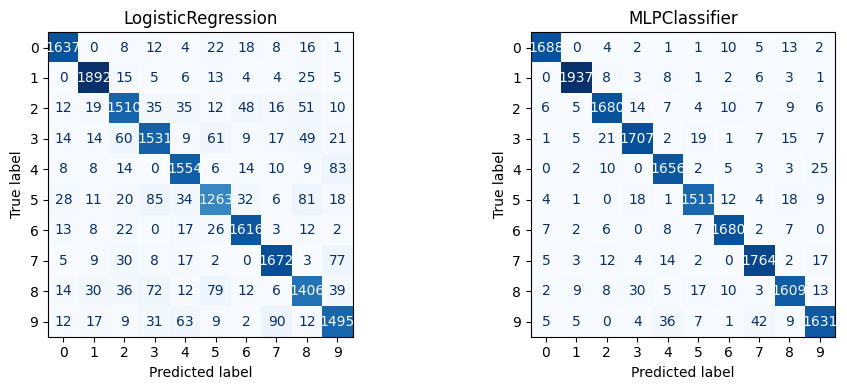

In [4]:
baseline_results = run_default_baseline_suite(
    mnist_split,
    seed=data_seed,
    mlp_hidden_layer_sizes=(64,),
)
display_baseline_suite(baseline_results, class_names)


## 3. Standard Superposition Activations


In [ ]:
standard_result = run_quantum_experiment(
    "standard",
    label="MNIST standard superposition activations",
    split=mnist_split,
    hidden_units=hidden_units,
    n_qubits=n_qubits,
    steps=steps,
    learning_rate=learning_rate,
    seed=data_seed,
    log_every=log_every,
    snapshot_interval=snapshot_interval,
    eval_shots=eval_shots,
    use_jax=use_jax,
    batch_size=batch_size,
    show_training_progress=show_training_progress,
)
display_quantum_result(standard_result, class_names)


Training 60 epochs on JAX (gpu), batch_size=1024…


### Standard Training Process (Snapshots)


In [ ]:
plot_training_diagnostics(standard_result)


## 4. Mode A Signed Superposition Activations


In [ ]:
mode_a_result = run_quantum_experiment(
    "mode_a",
    label="MNIST Mode A superposition activations",
    split=mnist_split,
    hidden_units=hidden_units,
    n_qubits=n_qubits,
    steps=steps,
    learning_rate=learning_rate,
    seed=data_seed,
    log_every=log_every,
    snapshot_interval=snapshot_interval,
    eval_shots=eval_shots,
    use_jax=use_jax,
    batch_size=batch_size,
    show_training_progress=show_training_progress,
)
display_quantum_result(mode_a_result, class_names)


### Mode A Training Process (Snapshots)


In [ ]:
plot_training_diagnostics(mode_a_result)


## 5. Mode B Signed Superposition Activations


In [ ]:
mode_b_result = run_quantum_experiment(
    "mode_b",
    label="MNIST Mode B superposition activations",
    split=mnist_split,
    hidden_units=hidden_units,
    n_qubits=n_qubits,
    steps=steps,
    learning_rate=learning_rate,
    seed=data_seed,
    log_every=log_every,
    snapshot_interval=snapshot_interval,
    eval_shots=eval_shots,
    use_jax=use_jax,
    batch_size=batch_size,
    show_training_progress=show_training_progress,
)
display_quantum_result(mode_b_result, class_names)


### Mode B Training Process (Snapshots)


In [ ]:
plot_training_diagnostics(mode_b_result)


## 6. Final Comparison


In [ ]:
comparison_rows = build_comparison_rows(
    baseline_results,
    [standard_result, mode_a_result, mode_b_result],
)
print_comparison_table(comparison_rows)
